In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [5]:
df = pd.read_csv("../data/raw/wue_csv.csv")

### Pulizia dei dati

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month'] = df['timestamp'].dt.month

In [7]:
print(df['country'].unique(),"paesi")

<StringArray>
[                'Cameroon',               'Mauritania',
                  'Eritrea',                  'Nigeria',
                  'Lesotho',                  'Algeria',
        'Equatorial Guinea',                  'Somalia',
             'Sierra Leone',                 'Ethiopia',
                  'Namibia',                  'Tunisia',
             'South Africa',                   'Malawi',
               'Madagascar',                    'Kenya',
 'Central African Republic',                     'Togo',
              'South Sudan',                  'Senegal',
                  'Burundi',               'Seychelles',
               'Cape Verde',                   'Guinea',
                 'Zimbabwe',                     'Mali',
                     'Chad',                    'Ghana',
                    'Benin',                    'Niger',
                 'Tanzania',                   'Zambia',
               'Mozambique',                 'Botswana',
             'Bur

In [12]:
print(df['climate_region'].value_counts())

climate_region
Savana           1338096
Steppe            737856
Desert            620736
Mediterranean     204936
Rainforest        140544
Name: count, dtype: int64


### Quali sono i paesi più efficienti nell'utilizzo dell'acqua?

Una domanda che i detentori dei datacenter potrebbero porsi quando si affronta il tema della sostenbilità potrebbe essere dove sia meglio costruire i datacenter. Possiamo ricavare questo dato analizzando i paesi con il WUE più basso. 

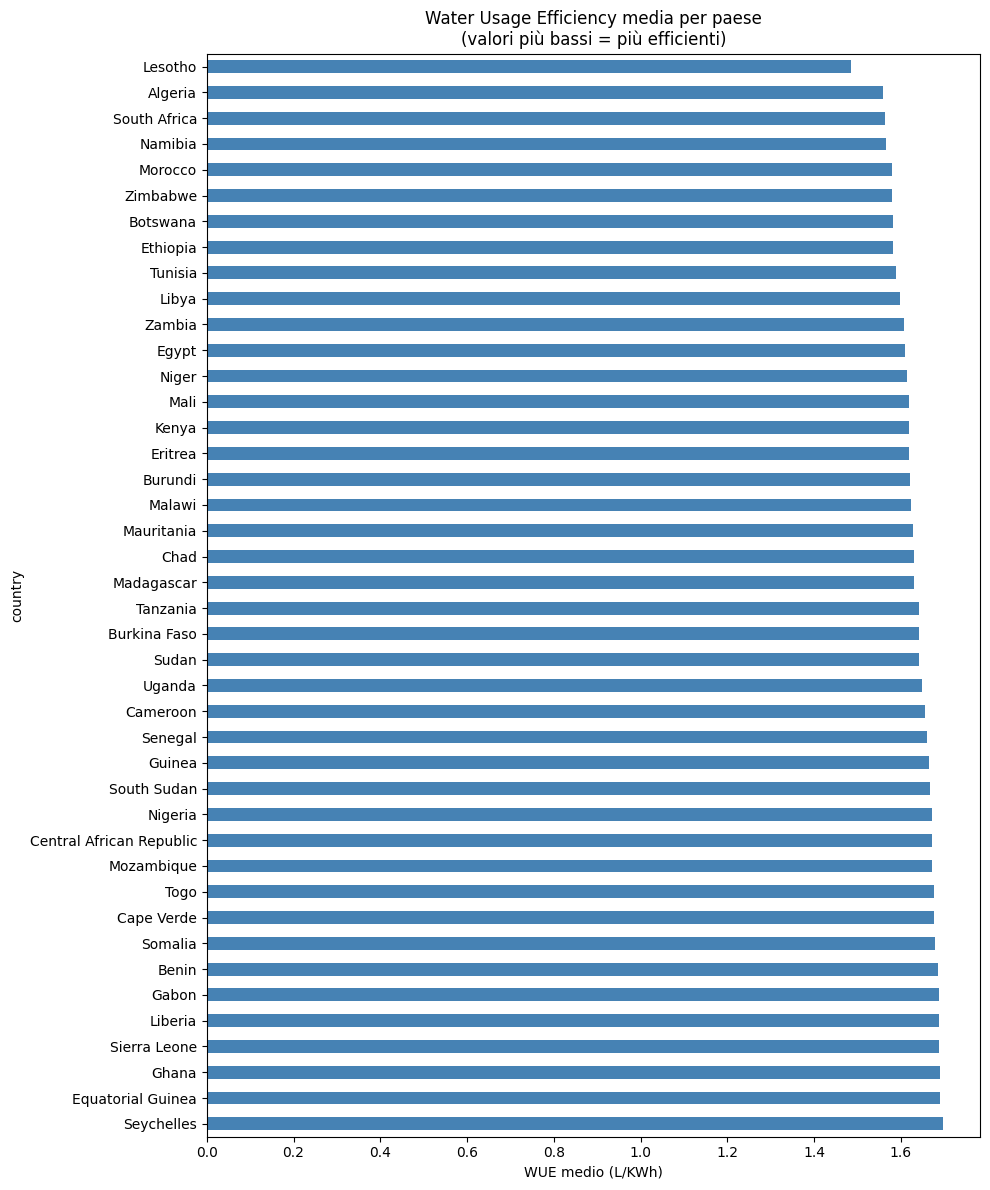

In [16]:
wue_by_country = df.groupby('country')['WUE_FixedApproachDirect(L/KWh)'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 12))
wue_by_country.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('WUE medio (L/KWh)')
ax.set_title('Water Usage Efficiency media per paese\n(valori più bassi = più efficienti)')
plt.tight_layout()
plt.savefig('../output/figures/wue_per_paese.png', dpi=150)
plt.show()

### Nelle diverse regioni climatiche, quanto varia la wue mensilmente?

Il motivo dietro questa domanda, era inizialmente quello di osservare in base alle stagioni quanto questo cambiasse. 
Il clima influenza molto la quantità di acqua che serve per rafreddare i datacenter. Intuitivamente, verrebbe da pensare che nelle regioni in cui fa più caldo, serva pià acqua. 

Il grafico ci fornisce veramente moltissime informazioni.

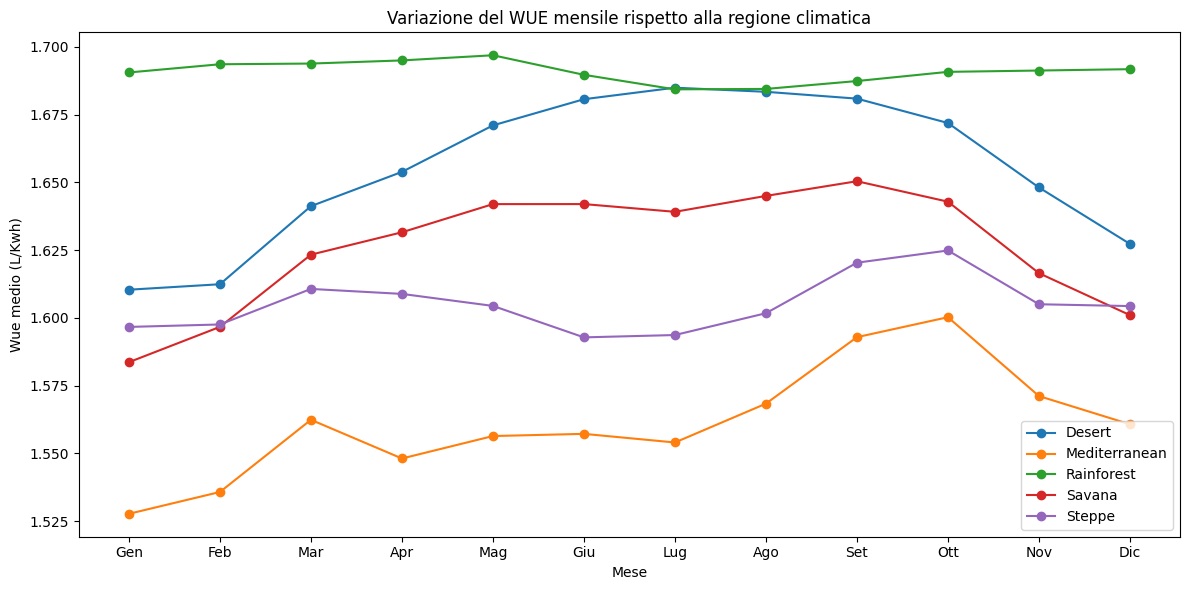

In [37]:
monthly_wue = df.groupby(['climate_region','month'])['WUE_FixedApproachDirect(L/KWh)'].mean().reset_index()

fig, ax =  plt.subplots(figsize=(12,6))
for region in monthly_wue['climate_region'].unique():
    #prendi i dati dobe le regioni sono uguali
    data_to_show = monthly_wue[monthly_wue['climate_region']==region]
    ax.plot(data_to_show['month'],data_to_show['WUE_FixedApproachDirect(L/KWh)'],marker='o',label=region)

ax.set_xlabel("Mese")
ax.set_ylabel("Wue medio (L/Kwh)")
ax.set_title("Variazione del WUE mensile rispetto alla regione climatica")
ax.legend()
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic'])
plt.tight_layout()
plt.savefig('../output/figures/wue_mensile_x_regioneclimatica.png',dpi=150)
plt.show()


### Possedere fonti rinnovabili vuol dire perforza avere un uso efficiente dell'acqua?

Il grafico realizzato mostra in realtà delle cose molto interessanti.
I paesi che hanno un altra percentuale di energia da fonti rinnovabili hanno un WUE indiretto abbastanza alto, tra i più alti del continente. 
Invece i paesi desertici che non sfruttano più di tanto energia rinnovabile hanno un wue indiretto un più bassa.
Questo ci porta a presupporre che magari hanno contributo da parte dell’idroelettrico molto importante, tipo di energia che molti paesi non possono sfruttare più di tanto.

L’ipotesi si basa sia sulla struttura geografica del paese ma anche sull’effettiva analisi della percentuale di idroelettrico che c’è nei paesi in alto a destra del grafico.

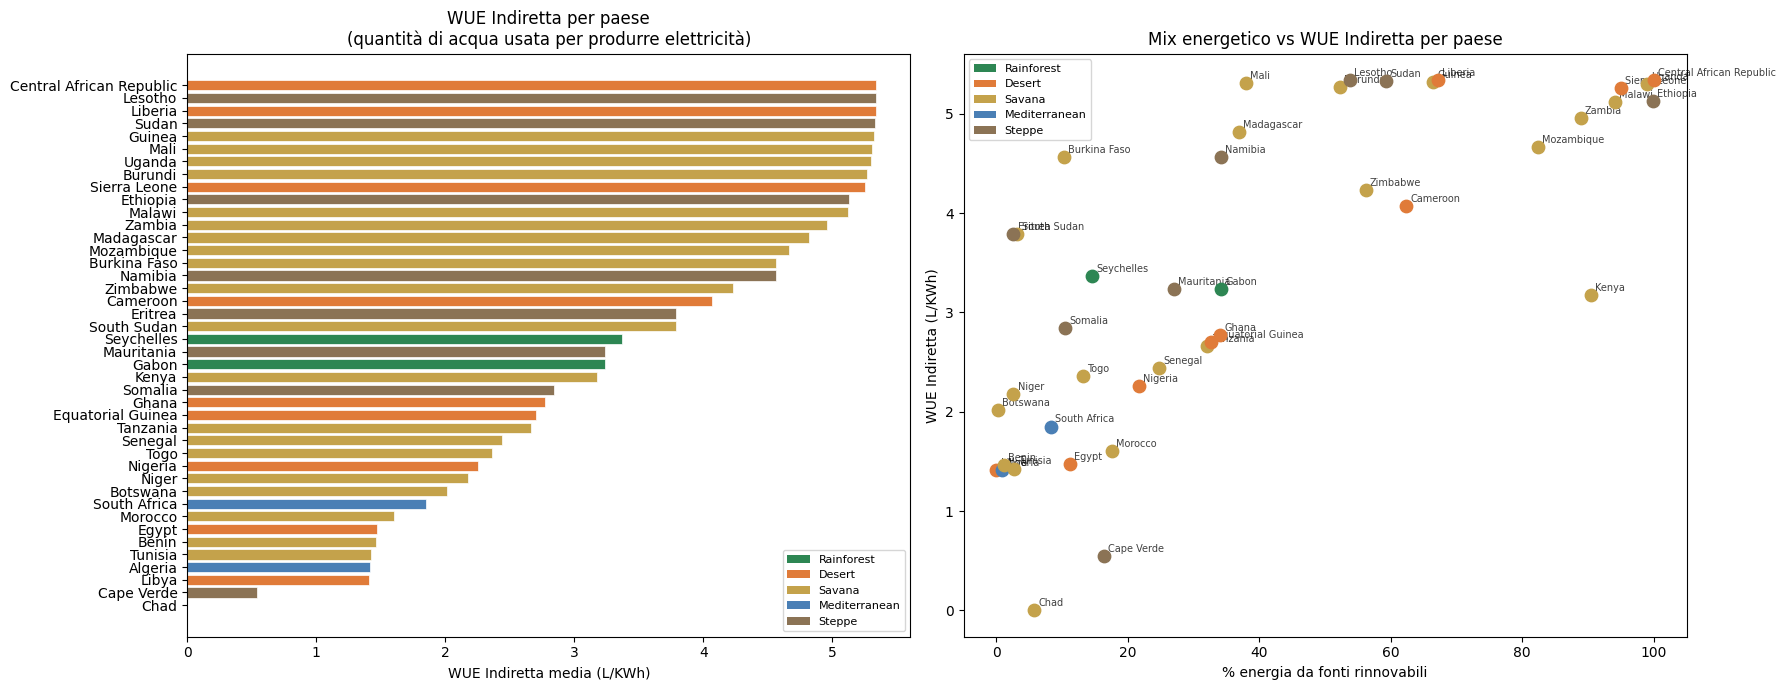

'\nprint("\nTop 5 paesi più efficienti (WUE Indirect più bassa):")\nprint(country_indirect[[\'country\', \'climate_region\', \'wue_indirect\', \'renewables_pct\']]\n      .head(5).to_string(index=False))\n\nprint("\nTop 5 paesi meno efficienti (WUE Indirect più alta):")\nprint(country_indirect[[\'country\', \'climate_region\', \'wue_indirect\', \'renewables_pct\']]\n      .tail(5).to_string(index=False))\n'

In [10]:
# Aggrega per paese — media annuale (valore già quasi costante per paese/anno)
country_indirect = df.groupby(['country', 'climate_region']).agg(
    wue_indirect=('WUE_Indirect(L/KWh)', 'mean'),
    renewables_share=('Total renewables - TWh', 'mean'),
    total_energy=('Total energy - TWh', 'mean')
).reset_index()


country_indirect['renewables_pct'] = (
    country_indirect['renewables_share'] / country_indirect['total_energy'] * 100
).round(1)

country_indirect = country_indirect.sort_values('wue_indirect', ascending=True)


#bar
palette = {
    'Rainforest': '#2d8653',
    'Desert': '#e07b39',
    'Savana': '#c4a24b',      # ← una sola 'n'
    'Mediterranean': '#4a7fb5',
    'Steppe': '#8b7355'
}
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = [palette.get(r, 'gray') for r in country_indirect['climate_region']]
bars = axes[0].barh(country_indirect['country'], country_indirect['wue_indirect'],
                     color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('WUE Indiretta media (L/KWh)')
axes[0].set_title('WUE Indiretta per paese\n(quantità di acqua usata per produrre elettricità)')

# Legenda 
legend_elements = [Patch(facecolor=c, label=r) for r, c in palette.items()]
axes[0].legend(handles=legend_elements, fontsize=8, loc='lower right')

# --- Scatter: % rinnovabili vs WUE Indiretta ---
for _, row in country_indirect.iterrows():
    color = palette.get(row['climate_region'], 'gray')
    axes[1].scatter(row['renewables_pct'], row['wue_indirect'],
                    color=color, s=80, zorder=5)
    axes[1].annotate(row['country'], (row['renewables_pct'], row['wue_indirect']),
                     fontsize=7, alpha=0.75, xytext=(3, 3),
                     textcoords='offset points')

axes[1].set_xlabel('% energia da fonti rinnovabili')
axes[1].set_ylabel('WUE Indiretta (L/KWh)')
axes[1].set_title('Mix energetico vs WUE Indiretta per paese')
axes[1].legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig('../output/figures/03_wue_indirect_per_paese.png', dpi=150)
plt.show()

"""
print("\nTop 5 paesi più efficienti (WUE Indirect più bassa):")
print(country_indirect[['country', 'climate_region', 'wue_indirect', 'renewables_pct']]
      .head(5).to_string(index=False))

print("\nTop 5 paesi meno efficienti (WUE Indirect più alta):")
print(country_indirect[['country', 'climate_region', 'wue_indirect', 'renewables_pct']]
      .tail(5).to_string(index=False))
"""

In [61]:
print(df.groupby('climate_region')['country'].nunique().sort_values(ascending=False))

climate_region
Savana           21
Desert            9
Steppe            8
Mediterranean     2
Rainforest        2
Name: country, dtype: int64


Proviamo ad analizzare i primi 3 paesi con wue più alto e i primi 3 paesi con wue più basso 

### Dipende veramente dall'idroelettrico? 

La seguente analisi ce lo conferma chiaramente. I primi 5 paesi con un altra percentuale di rinnovabile hanno una componente significativa per quanto riguarda l'energia idroelettrica.
Per i 5 paesi con wue indiretto più basso, 


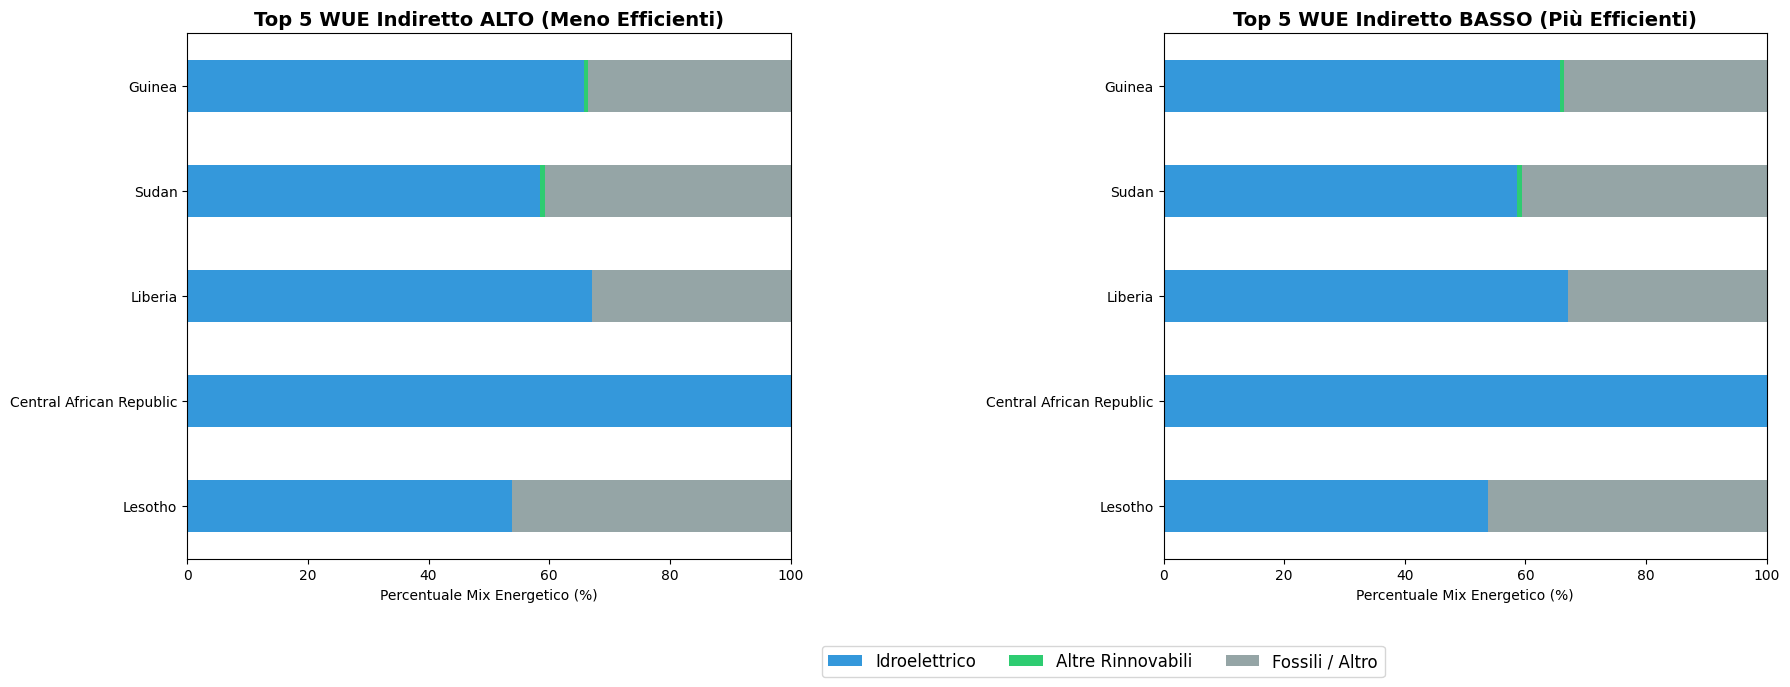

In [11]:
# energie rinnovabili e non rinnovabili 
df['Non-Renewables - TWh'] = df['Total energy - TWh'] - df['Total renewables - TWh']
df['Other Renewables - TWh'] = df['Total renewables - TWh'] - df['Hydro consumption - TWh']


energy_mix = df.groupby('country').agg({
    'WUE_Indirect(L/KWh)': 'mean',
    'Hydro consumption - TWh': 'mean',
    'Other Renewables - TWh': 'mean',
    'Non-Renewables - TWh': 'mean',
    'Total energy - TWh': 'mean'
}).reset_index()

sources = ['Hydro consumption - TWh', 'Other Renewables - TWh', 'Non-Renewables - TWh']
for source in sources:
    energy_mix[source + ' %'] = (energy_mix[source] / energy_mix['Total energy - TWh']) * 100

top5_highWueIndirect = energy_mix.sort_values('WUE_Indirect(L/KWh)', ascending=False).head(5)
top5_lowWueIndirect = energy_mix.sort_values('WUE_Indirect(L/KWh)', ascending=True).head(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

plot_data = [
    (top5_highWueIndirect, ax1, 'Top 5 WUE Indiretto ALTO (Meno Efficienti)'),
    (top5_highWueIndirect, ax2, 'Top 5 WUE Indiretto BASSO (Più Efficienti)')
]

colors = ['#3498db', '#2ecc71', '#95a5a6'] 
labels = ['Idroelettrico', 'Altre Rinnovabili', 'Fossili / Altro']

for data, ax, title in plot_data:
    data.set_index('country')[[s + ' %' for s in sources]].plot(
        kind='barh', stacked=True, ax=ax, color=colors, legend=False
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Percentuale Mix Energetico (%)')
    ax.set_ylabel('')

# leggenda
ax2.legend(labels, loc='upper center', bbox_to_anchor=(-0.1, -0.15), ncol=3, fontsize=12)
plt.tight_layout()
plt.show()